# Topic 5 — Multiclass Classification: TensorFlow vs sklearn

Dataset: [AeroScan Military Aircraft](https://www.kaggle.com/datasets/ahnuf05/aeroscan-military-aircraft-classification)  
88 aircraft classes (YOLO `class_id` 0–87, read from each `.txt` annotation file).

**Progression**: flat MLP (baseline) → CNN → vary kernel size → vary stride → vary padding.  
Low resolution (32×32) loses spatial structure in a flat MLP — convolutions exploit it instead.

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

print('TF version:', tf.__version__)

TF version: 2.21.0


## 1. Download dataset via kagglehub

In [43]:
import kagglehub

path = kagglehub.dataset_download('ahnuf05/aeroscan-military-aircraft-classification')
print('Dataset path:', path)

TRAIN_DIR = os.path.join(path, 'train')
TEST_DIR  = os.path.join(path, 'test')

Dataset path: /Users/edwinperez/.cache/kagglehub/datasets/ahnuf05/aeroscan-military-aircraft-classification/versions/1


## 2. Load images

No subfolders, no class-name yaml — labels come from the YOLO `class_id`
(first number in each `.txt`). Empty `.txt` = background image, skipped here.

In [59]:
IMG_SIZE      = 48   # increased from 32 — more detail helps convolutions
MAX_PER_CLASS = 150

def get_class_id(txt_path):
    with open(txt_path) as f:
        line = f.readline().strip()
    return int(line.split()[0]) if line else None

def load_images(directory, img_size=IMG_SIZE, max_per_class=MAX_PER_CLASS):
    images, labels = [], []
    counts = {}
    for fname in sorted(os.listdir(directory)):
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        txt_path = os.path.join(directory, os.path.splitext(fname)[0] + '.txt')
        if not os.path.exists(txt_path):
            continue
        cls_id = get_class_id(txt_path)
        if cls_id is None or counts.get(cls_id, 0) >= max_per_class:
            continue
        img = Image.open(os.path.join(directory, fname)).convert('RGB')
        images.append(np.array(img.resize((img_size, img_size))) / 255.0)
        labels.append(cls_id)
        counts[cls_id] = counts.get(cls_id, 0) + 1
    return np.array(images), np.array(labels)

X_train_raw, y_train = load_images(TRAIN_DIR)
X_test_raw,  y_test  = load_images(TEST_DIR)
N_CLASSES = len(np.unique(y_train))
print(f'Train: {X_train_raw.shape}  Test: {X_test_raw.shape}  N classes: {N_CLASSES}')

Train: (13200, 48, 48, 3)  Test: (2361, 48, 48, 3)  N classes: 88


In [60]:
X_train_flat = X_train_raw.reshape(len(X_train_raw), -1)
X_test_flat  = X_test_raw.reshape(len(X_test_raw),  -1)

## 3. Preview sample images

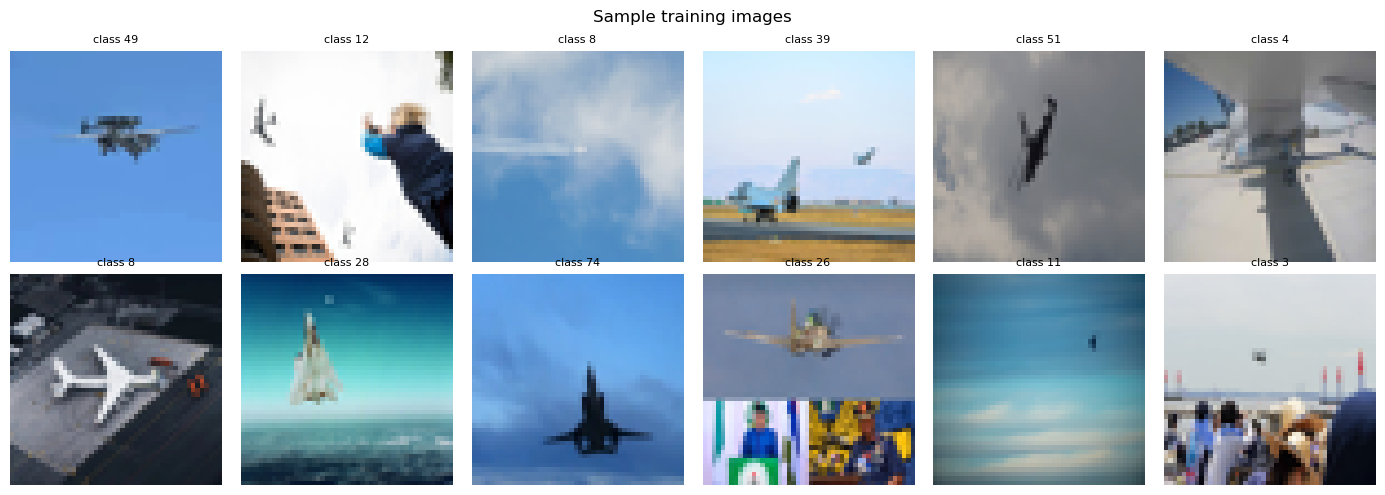

In [61]:
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
idx = np.random.choice(len(X_train_raw), 12, replace=False)
for ax, i in zip(axes.flat, idx):
    ax.imshow(X_train_raw[i])
    ax.set_title(f'class {y_train[i]}', fontsize=8)
    ax.axis('off')
plt.suptitle('Sample training images', fontsize=12)
plt.tight_layout(); plt.show()

## 4. Helper: train + evaluate any Keras model

Shared training loop so every architecture below is compared fairly
(same epochs, optimizer, callbacks).

In [62]:
def train_and_eval(model, name, epochs=40, batch_size=16):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0003),
        loss='sparse_categorical_crossentropy', metrics=['accuracy']
    )
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=8, restore_best_weights=True
    )
    hist = model.fit(
        X_train_raw, y_train, validation_data=(X_test_raw, y_test),
        epochs=epochs, batch_size=batch_size, callbacks=[early_stop], verbose=0
    )
    _, acc = model.evaluate(X_test_raw, y_test, verbose=0)
    print(f'{name:30s}  test_acc = {acc:.4f}  (n_params={model.count_params():,})')
    return model, hist, acc

results = {}   # collects (model, history, test_acc) per experiment

## 5. Baseline — flat MLP (no convolutions)

Same architecture as before: Flatten → 256 → 128 → softmax.

In [63]:
tf.random.set_seed(42)
mlp_model = keras.Sequential([
    keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(N_CLASSES, activation='softmax'),
], name='Flat_MLP')

results['Flat MLP'] = train_and_eval(mlp_model, 'Flat MLP')

Flat MLP                        test_acc = 0.0136  (n_params=1,813,976)


## 6. CNN baseline

Two Conv2D blocks (kernel=3, stride=1, padding='same') + pooling, then dense head.
Convolutions preserve spatial structure that flatten destroys.

In [64]:
def make_cnn(kernel_size=3, strides=1, padding='same', name='CNN'):
    return keras.Sequential([
        keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        keras.layers.Conv2D(32, kernel_size, strides=strides, padding=padding, activation='relu'),
        keras.layers.MaxPooling2D(2),
        keras.layers.Conv2D(64, kernel_size, strides=strides, padding=padding, activation='relu'),
        keras.layers.MaxPooling2D(2),
        keras.layers.Flatten(),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dropout(0.4),
        keras.layers.Dense(N_CLASSES, activation='softmax'),
    ], name=name)

tf.random.set_seed(42)
cnn_base = make_cnn(kernel_size=3, strides=1, padding='same', name='CNN_baseline')
results['CNN baseline (k=3,s=1,same)'] = train_and_eval(cnn_base, 'CNN baseline (k=3,s=1,same)')

CNN baseline (k=3,s=1,same)     test_acc = 0.0373  (n_params=1,210,520)


## 7. Varying kernel size

Larger kernels see more context per filter but reduce spatial resolution faster
and add more parameters. Stride and padding fixed at baseline (1, 'same').

In [65]:
for k in [3, 5, 7]:
    tf.random.set_seed(42)
    model = make_cnn(kernel_size=k, strides=1, padding='same', name=f'CNN_k{k}')
    results[f'kernel_size={k}'] = train_and_eval(model, f'kernel_size={k}')

kernel_size=3                   test_acc = 0.0368  (n_params=1,210,520)
kernel_size=5                   test_acc = 0.0343  (n_params=1,244,824)
kernel_size=7                   test_acc = 0.0326  (n_params=1,296,280)


## 8. Varying stride

Stride > 1 skips pixels between filter applications — downsamples faster,
fewer parameters in later layers, but coarser feature maps. Kernel fixed at 3.

In [66]:
for s in [1, 2, 3]:
    tf.random.set_seed(42)
    model = make_cnn(kernel_size=3, strides=s, padding='same', name=f'CNN_s{s}')
    results[f'stride={s}'] = train_and_eval(model, f'stride={s}')

stride=1                        test_acc = 0.0385  (n_params=1,210,520)
stride=2                        test_acc = 0.0529  (n_params=104,600)
stride=3                        test_acc = 0.0318  (n_params=39,064)


## 9. Varying padding

`'same'` pads input so output keeps the input size (per stride).
`'valid'` uses no padding — output shrinks, edge pixels get less coverage.
Kernel and stride fixed at baseline (3, 1).

In [ ]:
for p in ['same', 'valid']:
    tf.random.set_seed(42)
    model = make_cnn(kernel_size=3, strides=1, padding=p, name=f'CNN_{p}')
    results[f'padding={p}'] = train_and_eval(model, f'padding={p}')

## 10. Comparison summary

Experiment                       Test acc      Params
-----------------------------------------------------
Flat MLP                           0.0130   1,813,976
CNN baseline (k=3,s=1,same)        0.0286   1,210,520
kernel_size=3                      0.0216   1,210,520
kernel_size=5                      0.0251   1,244,824
kernel_size=7                      0.0199   1,296,280
stride=1                           0.0242   1,210,520
stride=2                           0.0199     104,600
stride=3                           0.0299      39,064
padding=same                       0.0255   1,210,520
padding=valid                      0.0286     850,072


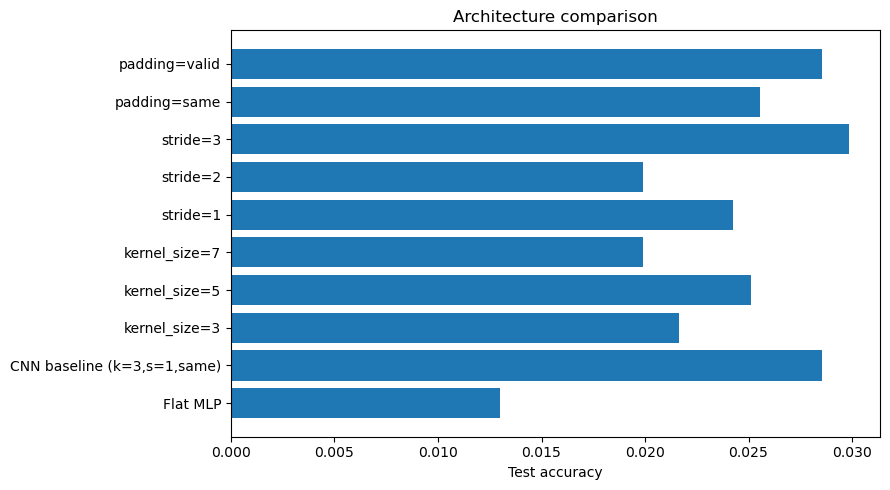

In [ ]:
print(f'{"Experiment":30s}  {"Test acc":>9}  {"Params":>10}')
print('-' * 53)
for name, (model, hist, acc) in results.items():
    print(f'{name:30s}  {acc:>9.4f}  {model.count_params():>10,}')

fig, ax = plt.subplots(figsize=(9, 5))
names = list(results.keys())
accs  = [results[n][2] for n in names]
ax.barh(names, accs, color='C0')
ax.set_xlabel('Test accuracy'); ax.set_title('Architecture comparison')
plt.tight_layout(); plt.show()

## 11. Best model — sklearn MLP comparison

sklearn has no Conv2D layers, so it is only compared against the flat-MLP baseline
(both operate on the same flattened pixel vectors).

In [ ]:
mlp_sk = MLPClassifier(
    hidden_layer_sizes=(256, 128), activation='relu', solver='adam',
    max_iter=40, random_state=42
)
mlp_sk.fit(X_train_flat, y_train)
sk_acc = mlp_sk.score(X_test_flat, y_test)

best_name = max(results, key=lambda n: results[n][2])
print(f'sklearn MLP (flat):            test_acc = {sk_acc:.4f}')
print(f'TF Flat MLP:                   test_acc = {results["Flat MLP"][2]:.4f}')
print(f'Best CNN config ({best_name}): test_acc = {results[best_name][2]:.4f}')

/Users/edwinperez/miniconda3/envs/advanced_lab_NN_packs/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (40) reached and the optimization hasn't converged yet.
  warnings.warn(


sklearn MLP (flat):            test_acc = 0.0143
TF Flat MLP:                   test_acc = 0.0130
Best CNN config (stride=3): test_acc = 0.0299


## 12. Confusion matrix and report — best model

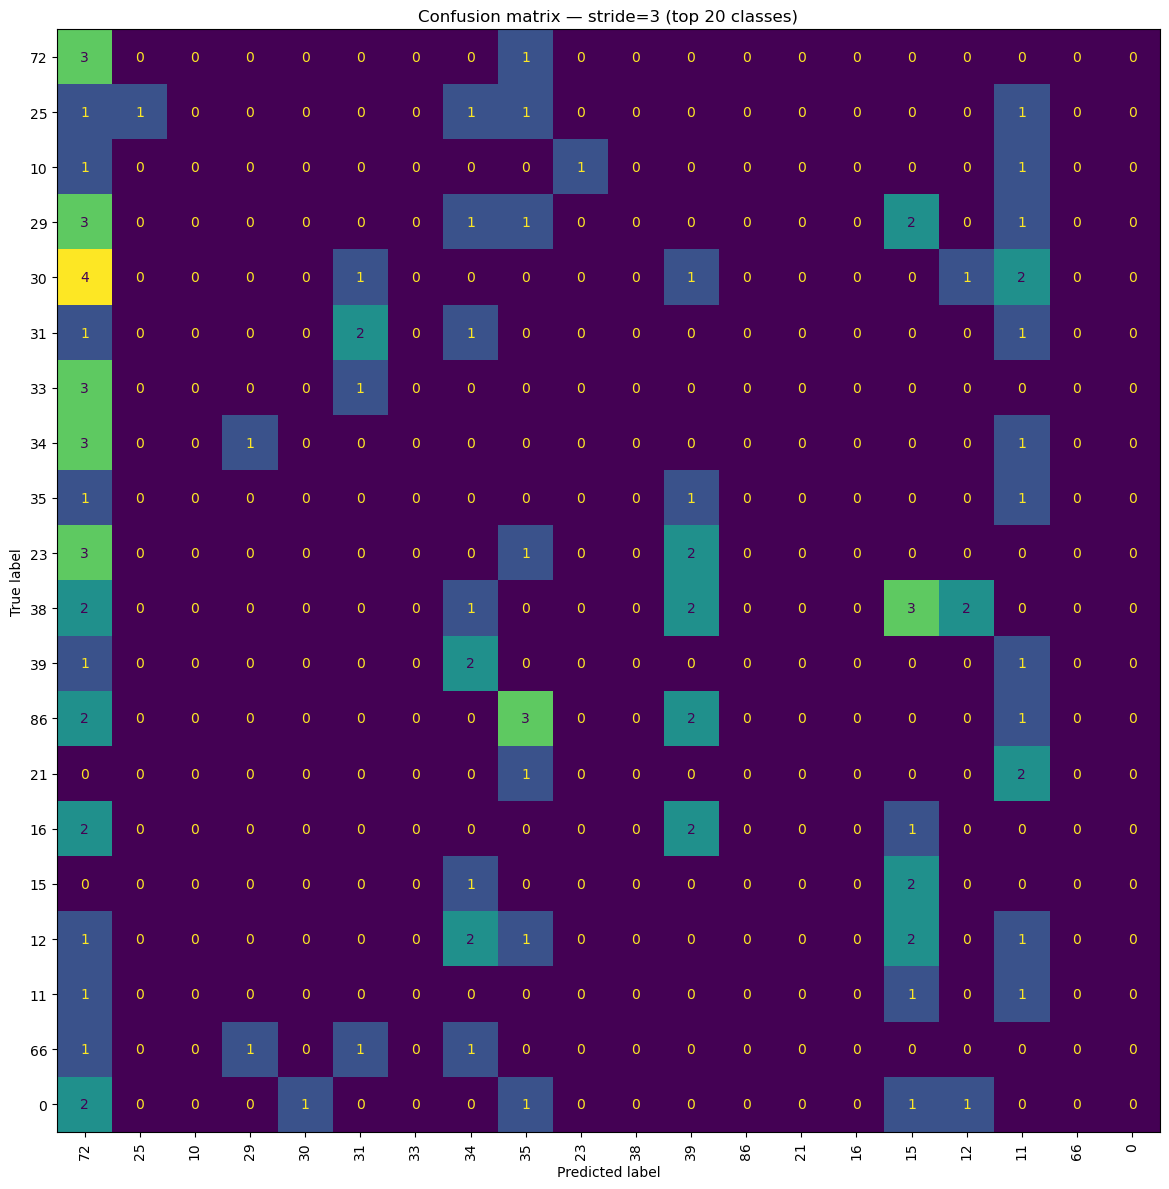

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        30
           1       0.00      0.00      0.00        25
           2       0.03      0.14      0.05        22
           3       0.11      0.03      0.05        30
           4       0.00      0.00      0.00        17
           5       0.50      0.04      0.07        27
           6       0.01      0.04      0.02        26
           7       0.00      0.00      0.00        25
           8       0.04      0.03      0.04        29
           9       0.00      0.00      0.00        27
          10       0.00      0.00      0.00        30
          11       0.02      0.03      0.02        30
          12       0.00      0.00      0.00        30
          13       0.00      0.00      0.00        18
          14       0.00      0.00      0.00        25
          15       0.05      0.07      0.05        30
          16       0.00      0.00      0.00        30
          17       0.00    

In [ ]:
best_model = results[best_name][0]
y_pred = np.argmax(best_model.predict(X_test_raw, verbose=0), axis=1)

top_classes = np.argsort(np.bincount(y_test))[-20:]
mask = np.isin(y_test, top_classes)

fig, ax = plt.subplots(figsize=(14, 12))
ConfusionMatrixDisplay.from_predictions(
    y_test[mask], y_pred[mask], labels=top_classes,
    display_labels=[str(c) for c in top_classes],
    xticks_rotation=90, ax=ax, colorbar=False
)
ax.set_title(f'Confusion matrix — {best_name} (top 20 classes)', fontsize=12)
plt.tight_layout(); plt.show()

print(classification_report(
    y_test, y_pred,
    labels=np.unique(y_train),
    target_names=[str(c) for c in np.unique(y_train)],
    zero_division=0
))

## 13. Inspect predictions on random test images

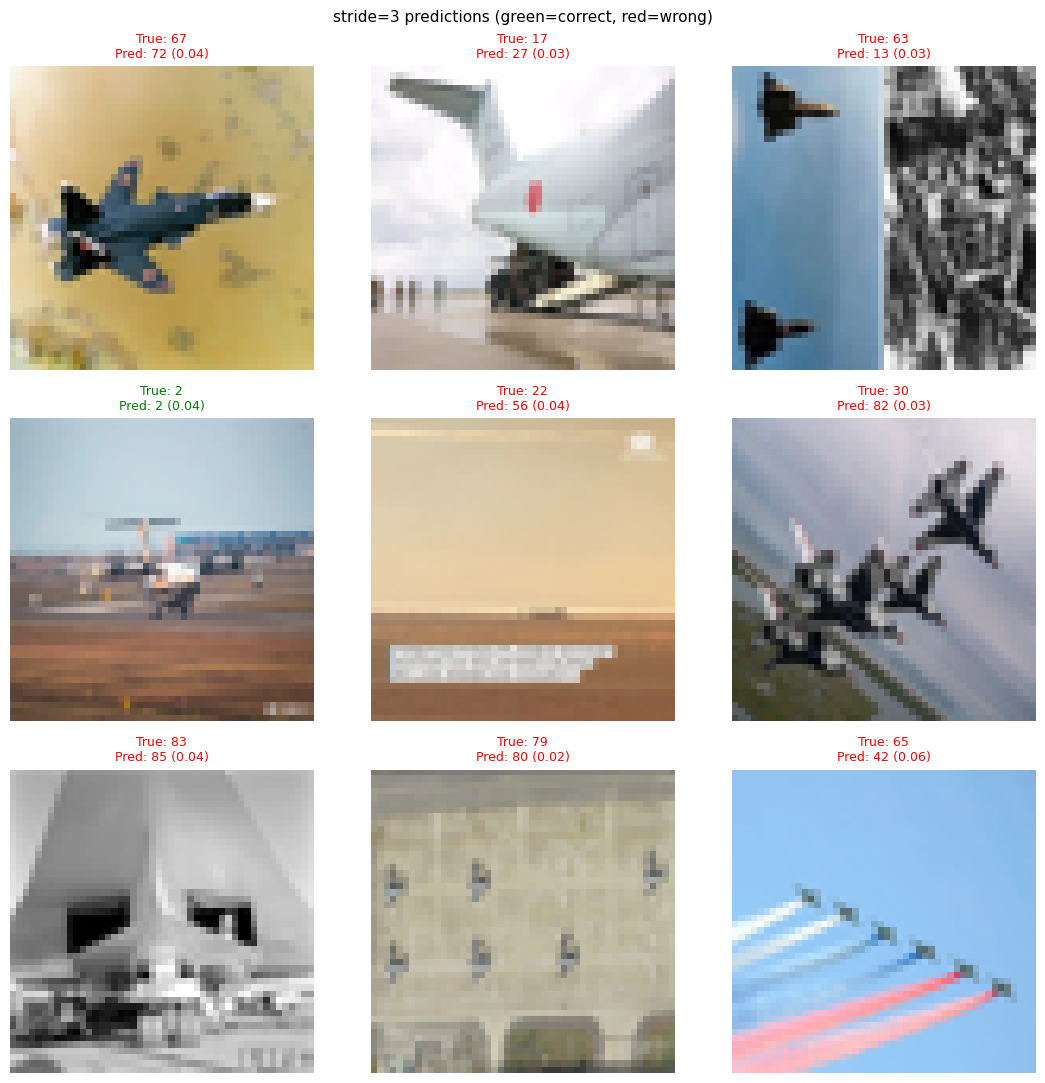

In [ ]:
idx   = np.random.choice(len(X_test_raw), 9, replace=False)
probs = best_model.predict(X_test_raw[idx], verbose=0)

fig, axes = plt.subplots(3, 3, figsize=(11, 11))
for ax, i, prob in zip(axes.flat, idx, probs):
    pred  = np.argmax(prob)
    conf  = prob[pred]
    color = 'green' if pred == y_test[i] else 'red'
    ax.imshow(X_test_raw[i])
    ax.set_title(f'True: {y_test[i]}\nPred: {pred} ({conf:.2f})', color=color, fontsize=9)
    ax.axis('off')
plt.suptitle(f'{best_name} predictions (green=correct, red=wrong)', fontsize=11)
plt.tight_layout(); plt.show()